# PCMCI + GPDCtorch — All Crops, Monthly

Two-phase analysis:

1. **Climate-only** (`climate`, 10 vars) — run once per crop, no RV. Recovers the nonlinear inter-variable causal structure within climate alone. Climate variables differ by crop growing region, so each crop gets its own climate graph.

2. **Per-crop RV analysis** (`climate_rv`, `macro_news_climate_rv`) — run per crop with crop-specific `weekly_rv`. Tests whether climate and macro/news variables nonlinearly Granger-cause each crop's realized volatility.

**Why GPDCtorch:** GP regression removes nonlinear additive conditional mean; Distance Correlation on residuals detects any remaining dependency. Detects curved climate→RV relationships that ParCorr misses.

Preprocessing identical to `eda_preprocessing.ipynb`: interpolate → ffill → Gaussian detrend (15-yr) → anomalize → `pp.trafo2normal`.

## 0. Imports & Configuration

In [1]:
import sys
from pathlib import Path

import time

ROOT = Path('.').resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats

from tigramite import data_processing as pp
from tigramite import plotting as tp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.gpdc_torch import GPDCtorch

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Configuration ─────────────────────────────────────────────────────────────
CROPS     = ['corn', 'soybean', 'wheat']
FREQUENCY = 'monthly'

CYCLE_LEN    = 12
SMOOTH_WIDTH = 15 * CYCLE_LEN   # 15-year Gaussian detrend window
TAU_MAX      = 3                # shorter than ParCorr: GP fitting degrades with wide conditioning sets

# GPDCtorch-specific parameters
# significance='analytic': pre-computes null distribution for T; avoids per-test shuffle cost
# sig_samples=200: number of samples used when caching the analytic null
GPDC_SIGNIFICANCE = 'analytic'
GPDC_SIG_SAMPLES  = 200

# pc_alpha=0.1: tighter than ParCorr's 0.2 — GPDC has lower power for linear links;
# tighter skeleton means fewer GP fits in the MCI step
PC_ALPHA     = 0.1
ALPHA_LEVEL  = 0.05
FDR_METHOD   = 'fdr_bh'

# max_combinations=1: MCI step tests only the single best conditioning set per link;
# essential for tractable runtime with GP fitting
MAX_COMBINATIONS = 3

print(f'Crops            : {CROPS}')
print(f'Frequency        : {FREQUENCY}')
print(f'tau_max          : {TAU_MAX}')
print(f'pc_alpha         : {PC_ALPHA}')
print(f'max_combinations : {MAX_COMBINATIONS}')
print(f'significance     : {GPDC_SIGNIFICANCE}')

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Crops            : ['corn', 'soybean', 'wheat']
Frequency        : monthly
tau_max          : 3
pc_alpha         : 0.1
max_combinations : 3
significance     : analytic


## 1. Device Detection

GPDCtorch uses `gpytorch` / `torch` for GP fitting. It automatically selects CUDA > MPS (Apple Silicon) > CPU.

In [2]:
try:
    import torch
    cuda_available = torch.cuda.is_available()
    mps_available  = getattr(getattr(torch, 'backends', None), 'mps', None) is not None \
                     and torch.backends.mps.is_available()
    backend = 'cuda' if cuda_available else 'mps' if mps_available else 'cpu'
    print(f'torch version  : {torch.__version__}')
    print(f'CUDA available : {cuda_available}')
    print(f'MPS available  : {mps_available}')
    print(f'Selected backend: {backend.upper()}')
    if backend == 'cpu':
        print('\nNote: running on CPU — expect longer runtimes. '
              'Each GP fit takes ~0.5–2 s; total for N=18, tau_max=3 can be 30–120 min.')
    # Set thread count for CPU parallelism
    torch.set_num_threads(4)
    print(f'torch threads  : {torch.get_num_threads()}')
except ImportError:
    print('torch not found — GPDCtorch will fall back to CPU via sklearn GP')

torch version  : 2.12.0
CUDA available : False
MPS available  : True
Selected backend: MPS
torch threads  : 4


## 2. Feature Group Definitions

| Group | Variables | N |
|-------|-----------|---|
| `rv` | `weekly_rv` | 1 |
| `climate` | `prcp`, `awnd`, `tmin`, `tmax`, `co2`, `pdsi`, `EVAP`, `soil_moisture_mean_m3m3`, `cloud_cover_mean_pct`, `humidity_mean_pct` | 10 |
| `macro` | `DJIA_Index`, `WTI_Index`, `Broad_Dollar_index`, `Stock_Uncertainty` | 4 |
| `news` | `frbsf_sentiment`, `epu_index`, `Text_Climate_Anomaly` | 3 |

**Phase 1 — climate-only (run per crop, no RV):**

| Feature Set | Groups | N | Why run separately |
|-------------|--------|---|--------------------|
| `climate` | climate | 10 | Climate causal structure is independent of RV; running without RV isolates physical chains and avoids RV acting as a collider |

**Phase 2 — per-crop RV analysis:**

| Feature Set | Groups | N | GPDCtorch consideration |
|-------------|--------|---|-------------------------|
| `climate_rv` | climate + rv | 11 | Primary nonlinear test: does climate Granger-cause RV beyond own-past? |
| `macro_news_climate_rv` | macro + news + climate + rv | 18 | Full model; `max_combinations=1` is essential here |

In [3]:
FEATURE_GROUPS = {
    'rv'     : ['weekly_rv'],
    'climate': ['prcp', 'awnd', 'tmin', 'tmax', 'co2', 'pdsi',
                'EVAP', 'soil_moisture_mean_m3m3', 'cloud_cover_mean_pct', 'humidity_mean_pct',
                'ssta_elino', 'ssta_lanina', 'SOI_index', 'NAO_index'],
    'macro'  : ['DJIA_Index', 'WTI_Index', 'Broad_Dollar_index', 'Stock_Uncertainty'],
    'news'   : ['frbsf_sentiment', 'epu_index', 'Text_Climate_Anomaly'],
}

GROUP_COLORS = {
    'rv': '#e41a1c', 'climate': '#377eb8', 'macro': '#4daf4a', 'news': '#984ea3',
}

FEATURE_SETS = {
    'climate'              : ['climate'],
    'climate_rv'           : ['climate', 'rv'],
    'macro_news_climate_rv': ['macro', 'news', 'climate', 'rv'],
}

def build_cols(groups: list[str]) -> list[str]:
    cols: list[str] = []
    for g in groups:
        cols.extend(FEATURE_GROUPS[g])
    return cols

def group_of(col: str) -> str:
    for g, cols in FEATURE_GROUPS.items():
        if col in cols:
            return g
    return 'other'

for name, groups in FEATURE_SETS.items():
    print(f'{name:30s}: {len(build_cols(groups)):2d} vars')

climate                       : 14 vars
climate_rv                    : 15 vars
macro_news_climate_rv         : 22 vars


## 3. Preprocessing Pipeline

**Identical to `eda_preprocessing.ipynb`** — same 4-step pipeline used for ParCorr.

| Step | Why it also matters for GPDCtorch |
|------|-----------------------------------|
| Impute (interpolate + ffill) | Avoids NaNs that break GP fitting |
| Gaussian detrend (15-yr) | Removes secular drift that the GP kernel would otherwise absorb as spurious long-range dependency |
| Anomalize (phase-wise) | Removes seasonal periodicity; if left in, GP's RBF kernel models it as a smooth pattern but cannot fully condition it out — inflates DC test statistic |
| `pp.trafo2normal` | Gaussianised marginals give better-conditioned GP covariance matrices; improves numerical stability and fit quality especially for heavy-tailed variables (EPU, EVAP) |

In [4]:
def load_and_preprocess(crop: str, frequency: str) -> tuple[np.ndarray, list[str], pd.Series]:
    """Load CSV, impute, detrend, anomalize, Gaussianise. Returns (arr_normal, col_names, dates)."""
    path = ROOT / 'data' / frequency / f'{crop}.csv'
    raw  = pd.read_csv(path, parse_dates=['date'])
    df   = raw.sort_values('date').reset_index(drop=True)

    # Impute
    for col in ['pdsi', 'Broad_Dollar_index']:
        if col in df.columns:
            df[col] = df[col].interpolate(method='linear', limit_direction='both')
    for col in ['DJIA_Index']:
        if col in df.columns:
            df[col] = df[col].ffill().bfill()
    df = df.dropna().reset_index(drop=True)

    col_names = [c for c in df.columns if c != 'date']
    arr = df[col_names].values.astype(float)

    # Detrend (15-year Gaussian smoother)
    cycle_len    = 52 if frequency == 'weekly' else 12
    smooth_width = 15 * cycle_len
    arr_detrended = pp.smooth(arr, smooth_width=smooth_width, kernel='gaussian', residuals=True)

    # Anomalize
    arr_anom = arr_detrended.copy().astype(float)
    for phase in range(cycle_len):
        idx = slice(phase, None, cycle_len)
        arr_anom[idx] -= arr_detrended[idx].mean(axis=0)
        std = arr_detrended[idx].std(axis=0)
        std[std == 0] = 1.0
        arr_anom[idx] /= std

    # Gaussianise
    arr_normal = pp.trafo2normal(arr_anom)

    return arr_normal, col_names, df['date']


print('Preprocessing function defined.')

Preprocessing function defined.


## 4. PCMCI + GPDCtorch Helpers

In [5]:
def run_gpdc(
    feature_set_name: str,
    col_names: list[str],
    arr_preprocessed: np.ndarray,
    all_cols: list[str],
    tau_max: int,
    pc_alpha: float = 0.1,
    alpha_level: float = 0.05,
    fdr_method: str = 'fdr_bh',
    max_combinations: int = 1,
    max_conds_dim: int | None = None,
    verbosity: int = 0,
) -> dict:
    """
    Run PCMCI + GPDCtorch on a named feature subset.

    max_combinations=1: test only the single most significant conditioning set per link.
    This is the primary runtime control for GPDCtorch — each GP fit is expensive.
    Setting it higher recovers more links but multiplies runtime proportionally.
    """
    indices     = [all_cols.index(c) for c in col_names]
    data_subset = arr_preprocessed[:, indices]

    dataframe = pp.DataFrame(
        data_subset,
        var_names=col_names,
        datatime={0: np.arange(len(data_subset))},
    )

    # Re-instantiate GPDCtorch each run: analytic null distribution is cached per T,
    # and the object holds internal state that should not be shared across feature sets.
    gpdc = GPDCtorch(
        significance=GPDC_SIGNIFICANCE,
        sig_samples=GPDC_SIG_SAMPLES,
    )
    pcmci = PCMCI(dataframe=dataframe, cond_ind_test=gpdc, verbosity=verbosity)

    print(f'\n  ── {feature_set_name} ({len(col_names)} vars, tau_max={tau_max}) ──')

    results = pcmci.run_pcmci(
        tau_min=1,
        tau_max=tau_max,
        pc_alpha=pc_alpha,
        alpha_level=alpha_level,
        fdr_method=fdr_method,
        max_combinations=max_combinations,
        max_conds_dim=max_conds_dim,
    )

    q_matrix = pcmci.get_corrected_pvalues(
        p_matrix=results['p_matrix'], tau_max=tau_max, fdr_method=fdr_method,
    )
    graph = pcmci.get_graph_from_pmatrix(
        p_matrix=q_matrix, alpha_level=alpha_level, tau_min=1, tau_max=tau_max,
    )
    results.update({
        'graph': graph, 'q_matrix': q_matrix,
        'pcmci': pcmci, 'col_names': col_names,
    })
    return results


def plot_results(results: dict, title: str, tau_max: int) -> None:
    col_names = results['col_names']
    n = len(col_names)

    tp.plot_graph(
        val_matrix=results['val_matrix'],
        graph=results['graph'],
        var_names=col_names,
        link_colorbar_label='cross-MCI (DC)',
        node_colorbar_label='auto-MCI',
        show_autodependency_lags=True,
        figsize=(max(8, n * 0.6), max(6, n * 0.5)),
    )
    plt.suptitle(f'{title}\ntau_max={tau_max} | FDR-BH α=0.05',
                 fontsize=11, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    tp.plot_time_series_graph(
        val_matrix=results['val_matrix'],
        graph=results['graph'],
        var_names=col_names,
        link_colorbar_label='MCI',
        figsize=(max(12, n * 0.8), 6),
    )
    plt.suptitle(f'{title} — time-series graph',
                 fontsize=11, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


def extract_rv_links(results: dict, alpha: float = 0.05) -> pd.DataFrame:
    col_names = results['col_names']
    if 'weekly_rv' not in col_names:
        return pd.DataFrame()
    rv_idx  = col_names.index('weekly_rv')
    q_mat   = results['q_matrix']
    val_mat = results['val_matrix']
    rows = [
        {'cause': col_names[j], 'lag': tau, 'val': val_mat[j, rv_idx, tau],
         'q_val': q_mat[j, rv_idx, tau]}
        for j in range(len(col_names))
        for tau in range(1, q_mat.shape[2])
        if q_mat[j, rv_idx, tau] < alpha
    ]
    return pd.DataFrame(rows)


print('PCMCI + GPDCtorch helpers defined.')

PCMCI + GPDCtorch helpers defined.


## 5. Parameter Summary

| Parameter | Value | Why for GPDCtorch |
|-----------|-------|-------------------|
| `tau_max` | **3** | GP fitting with large conditioning sets (many parents at many lags) is expensive and can overfit with T=192. tau_max=3 keeps the conditioning set manageable. |
| `pc_alpha` | **0.1** | GPDC has lower detection power for linear links than ParCorr. Tighter PC skeleton means fewer incorrect parents are carried into MCI, reducing spurious GP fits. Tutorial recommends 0.1 for GPDC. |
| `max_combinations` | **1** | MCI step tests only the single best-scoring conditioning set per link. Avoids combinatorial explosion of GP fits. |
| `max_conds_dim` | **None** | PC step's own pruning limits parent set size; capping separately would prematurely drop true parents. |
| `significance` | **`analytic`** | Pre-computes DC null distribution once per T; avoids shuffle testing overhead on every GP-residual pair. |
| `sig_samples` | **200** | Number of samples used when building the analytic null cache. |
| `alpha_level` | **0.05** | Final significance threshold after FDR-BH correction. |
| `fdr_method` | **`fdr_bh`** | Benjamini-Hochberg: controls expected false discovery rate across all tested links. |

## 6. Per-Crop RV Analysis (climate, climate_rv and macro_news_climate_rv)

Runs `climate_rv` and `macro_news_climate_rv` per crop.  
Only `weekly_rv` is crop-specific. Tests whether climate and macro/news nonlinearly Granger-cause each crop's realized volatility.

> **Runtime:** ~10–30 min per crop on CPU, ~2–6 min on MPS/CUDA.


######################################################################
  Phase 2 | CORN  |  FREQUENCY: MONTHLY
######################################################################
  Preprocessed: (192, 22)  (2009-04-01 → 2025-03-01)

  ── climete (14 vars, tau_max=3) ──
  Elapsed: 133.0 s

## Significant links at alpha = 0.05:

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 2 link(s):
        (tmin -1): pval = 0.00000 | val =  0.266
        (NAO_index -1): pval = 0.00000 | val =  0.238

    Variable tmax has 2 link(s):
        (tmax -3): pval = 0.00000 | val =  0.233
        (tmax -1): pval = 0.00000 | val =  0.229

    Variable co2 has 4 link(s):
        (co2 -1): pval = 0.00000 | val =  0.461
        (pdsi -2): pval = 0.00000 | val =  0.305
        (ssta_elino -1): pval = 0.00000 | val =  0.217
        (ssta_elino -3): pval = 0.00000 | val =  0.212

    Variable pdsi has 2 link(s):
        (prcp -1): pval = 0.00000 | val =  0.405
        

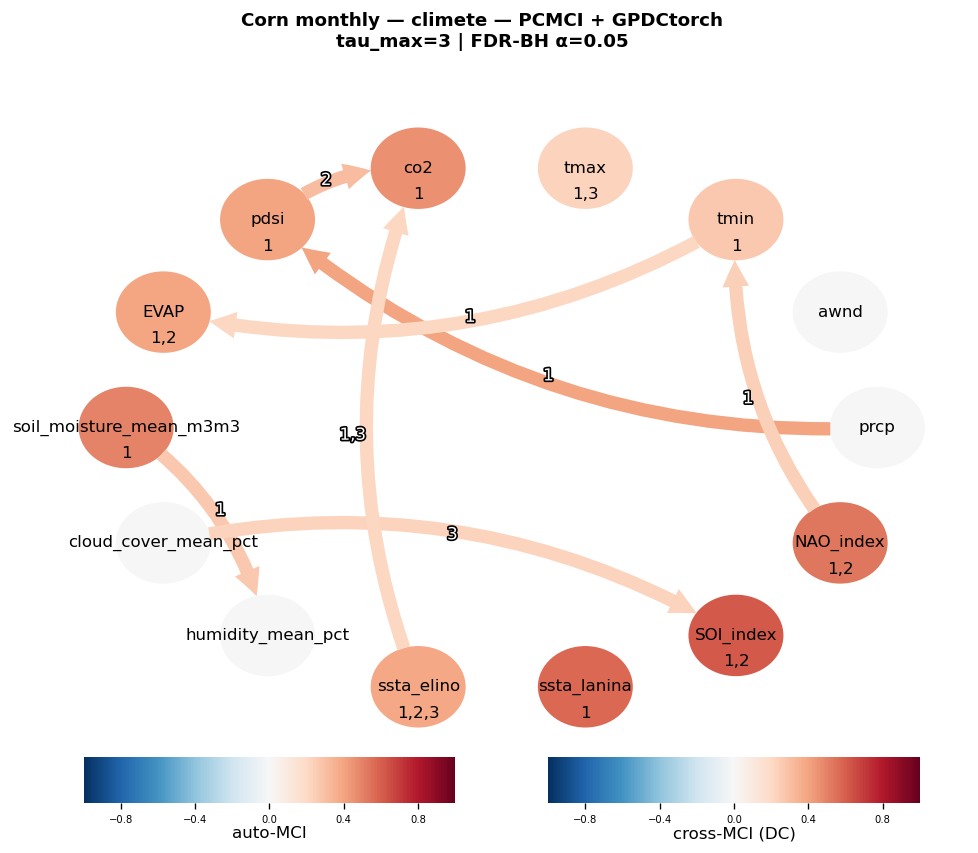

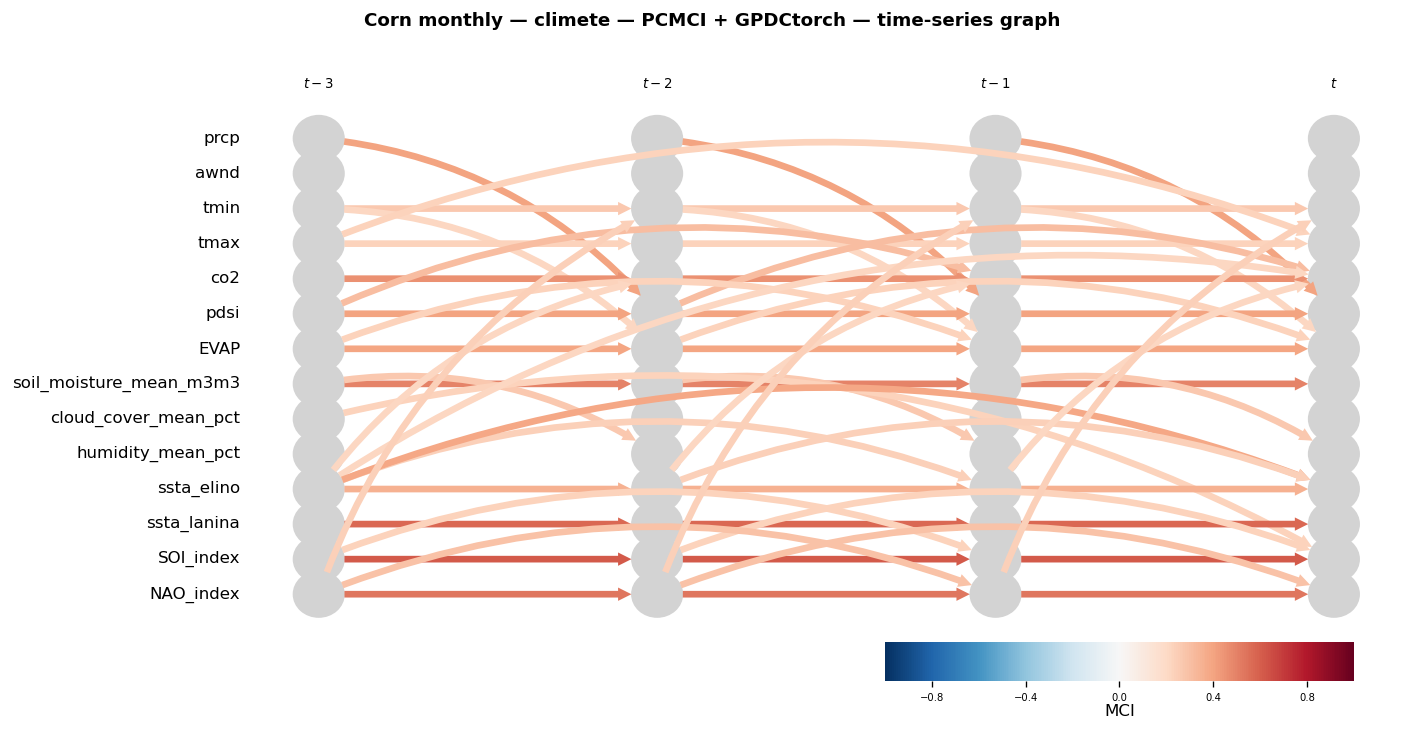


  ── climate_rv (15 vars, tau_max=3) ──
  Elapsed: 162.3 s

## Significant links at alpha = 0.05:

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 3 link(s):
        (NAO_index -1): pval = 0.00000 | val =  0.252
        (tmin -1): pval = 0.00000 | val =  0.231
        (ssta_lanina -3): pval = 0.00000 | val =  0.211

    Variable tmax has 2 link(s):
        (tmax -3): pval = 0.00000 | val =  0.217
        (NAO_index -1): pval = 0.00000 | val =  0.208

    Variable co2 has 4 link(s):
        (co2 -1): pval = 0.00000 | val =  0.461
        (pdsi -2): pval = 0.00000 | val =  0.229
        (ssta_elino -1): pval = 0.00000 | val =  0.217
        (ssta_elino -3): pval = 0.00000 | val =  0.212

    Variable pdsi has 2 link(s):
        (prcp -1): pval = 0.00000 | val =  0.404
        (pdsi -1): pval = 0.00000 | val =  0.376

    Variable EVAP has 4 link(s):
        (EVAP -1): pval = 0.00000 | val =  0.393
        (EVAP -2): pval = 0.00000 | val =  0.228

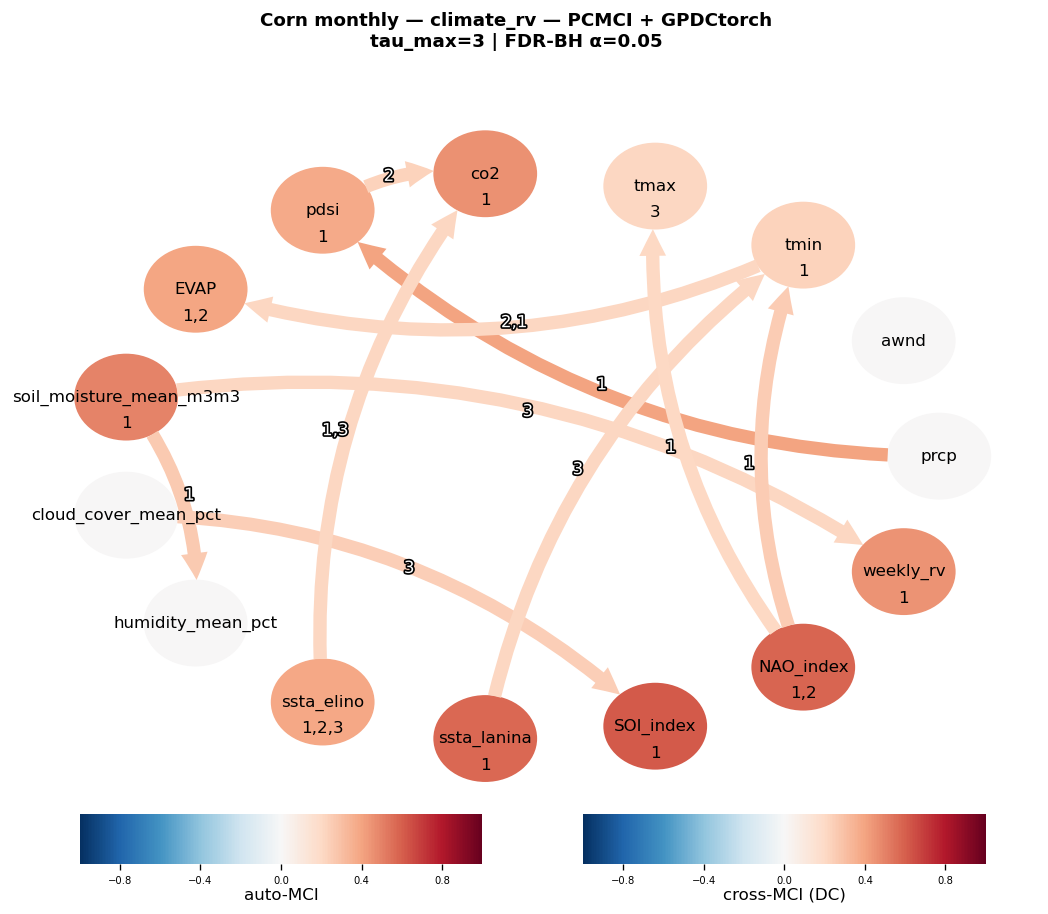

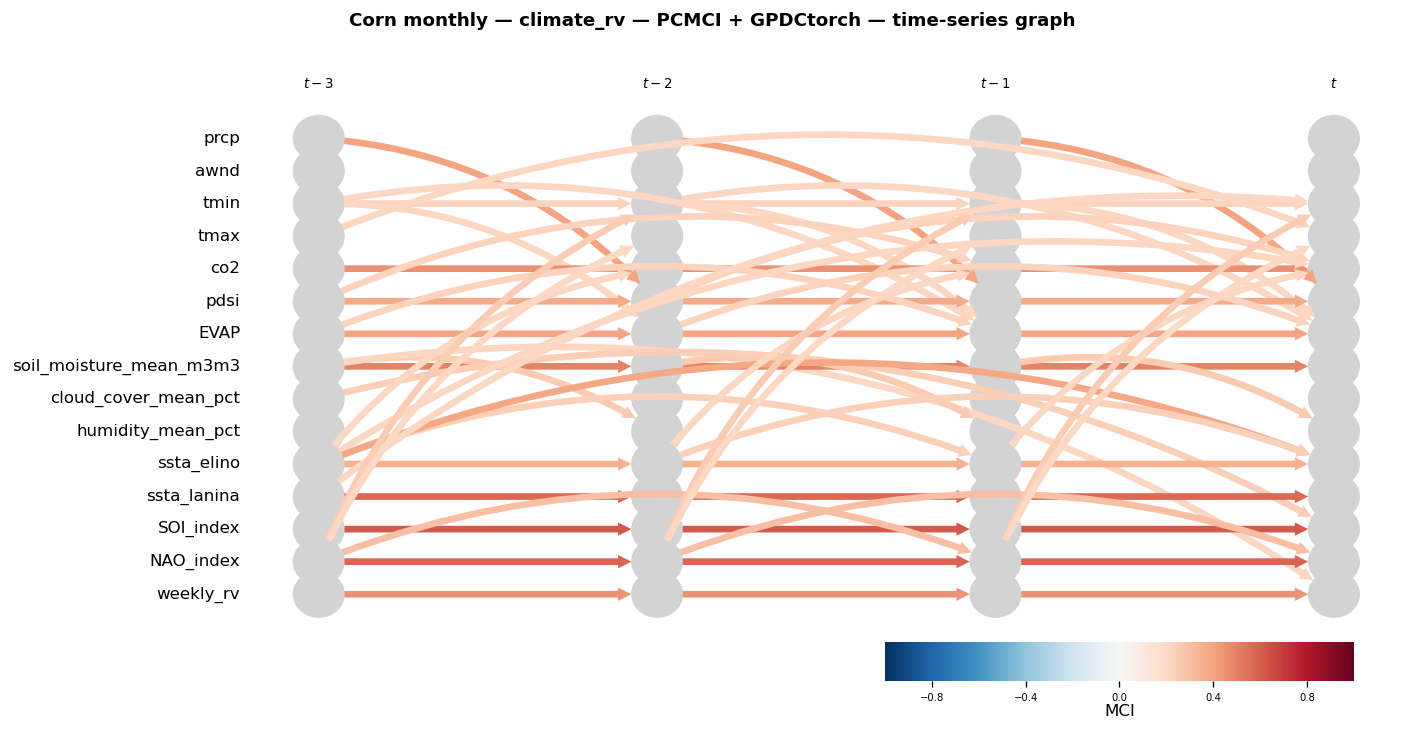


  ── macro_news_climate_rv (22 vars, tau_max=3) ──
  Elapsed: 379.1 s

## Significant links at alpha = 0.05:

    Variable DJIA_Index has 1 link(s):
        (DJIA_Index -1): pval = 0.00000 | val =  0.581

    Variable WTI_Index has 2 link(s):
        (WTI_Index -1): pval = 0.00000 | val =  0.716
        (epu_index -3): pval = 0.00000 | val =  0.217

    Variable Broad_Dollar_index has 2 link(s):
        (Broad_Dollar_index -1): pval = 0.00000 | val =  0.752
        (EVAP -1): pval = 0.00000 | val =  0.226

    Variable Stock_Uncertainty has 2 link(s):
        (Stock_Uncertainty -1): pval = 0.00000 | val =  0.446
        (WTI_Index -3): pval = 0.00000 | val =  0.243

    Variable frbsf_sentiment has 3 link(s):
        (frbsf_sentiment -1): pval = 0.00000 | val =  0.566
        (DJIA_Index -1): pval = 0.00000 | val =  0.278
        (Stock_Uncertainty -1): pval = 0.00000 | val =  0.253

    Variable epu_index has 3 link(s):
        (epu_index -1): pval = 0.00000 | val =  0.469
        (D

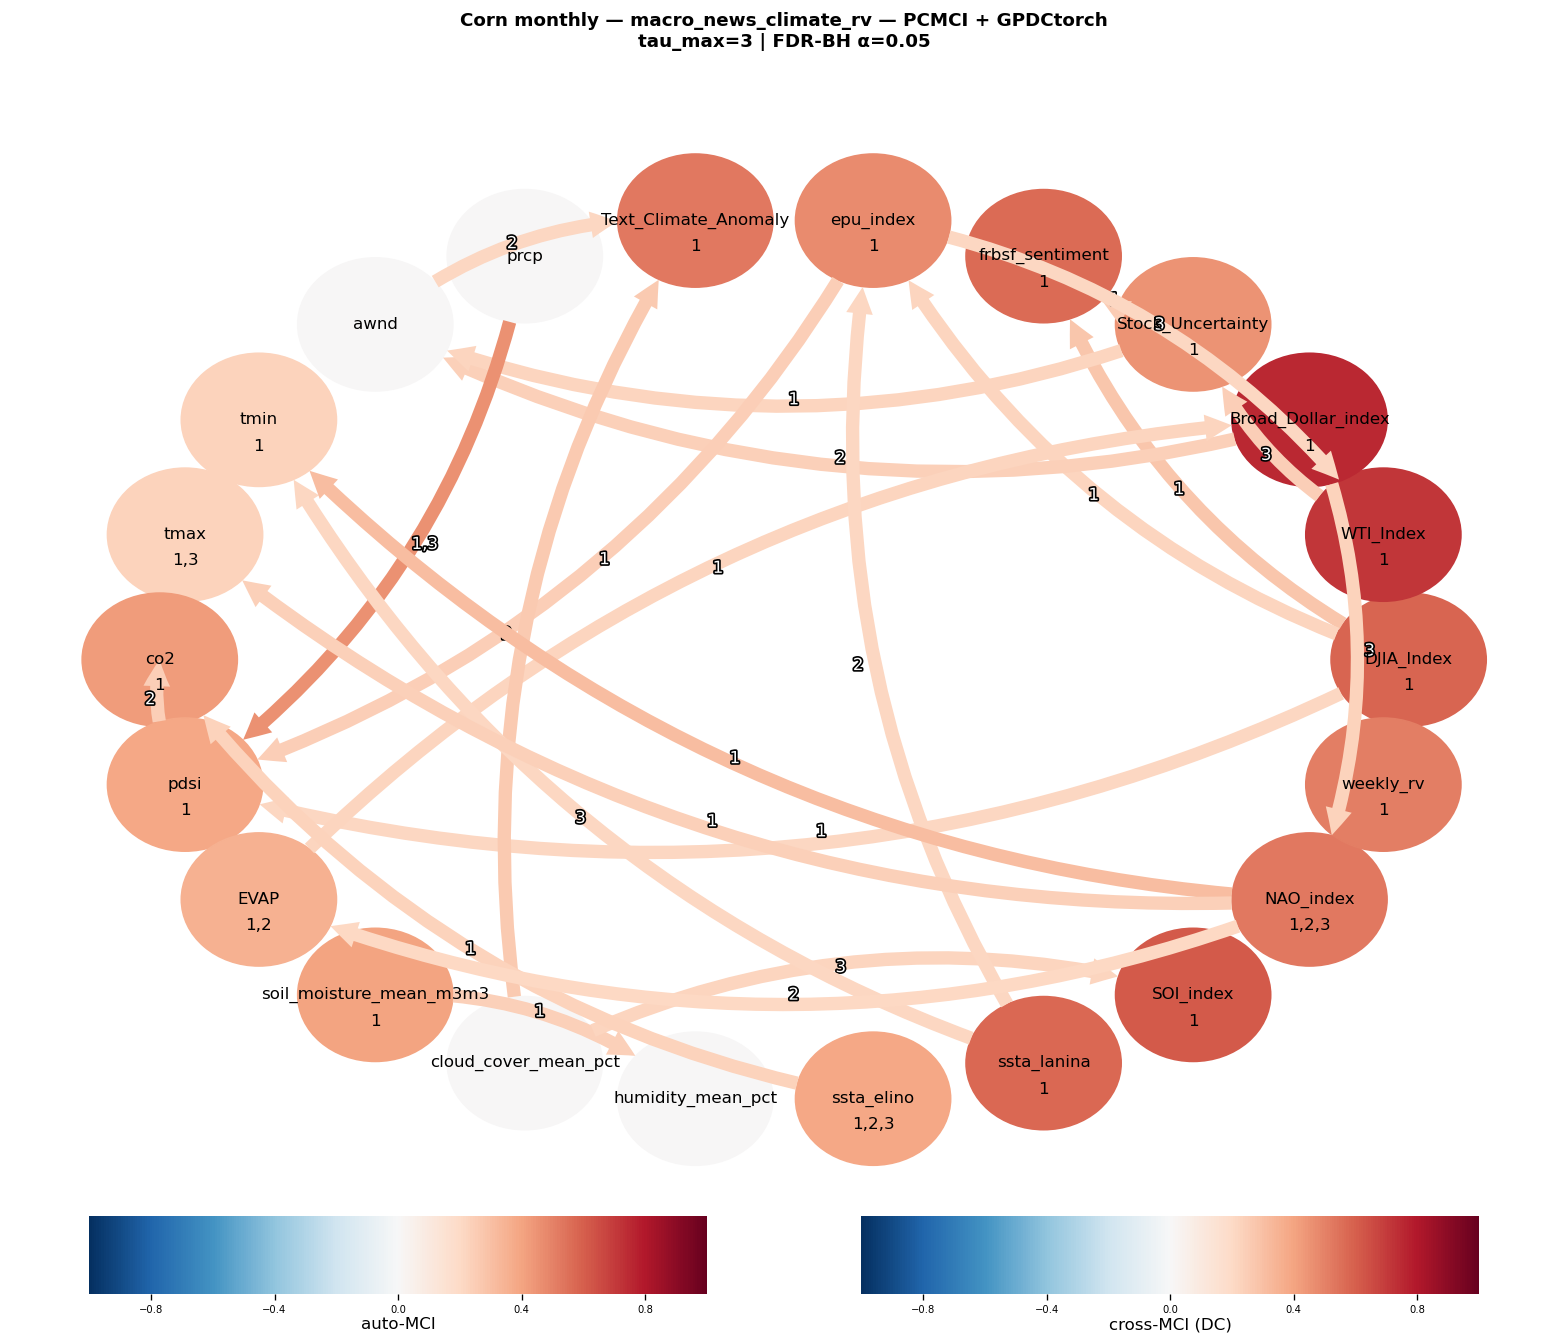

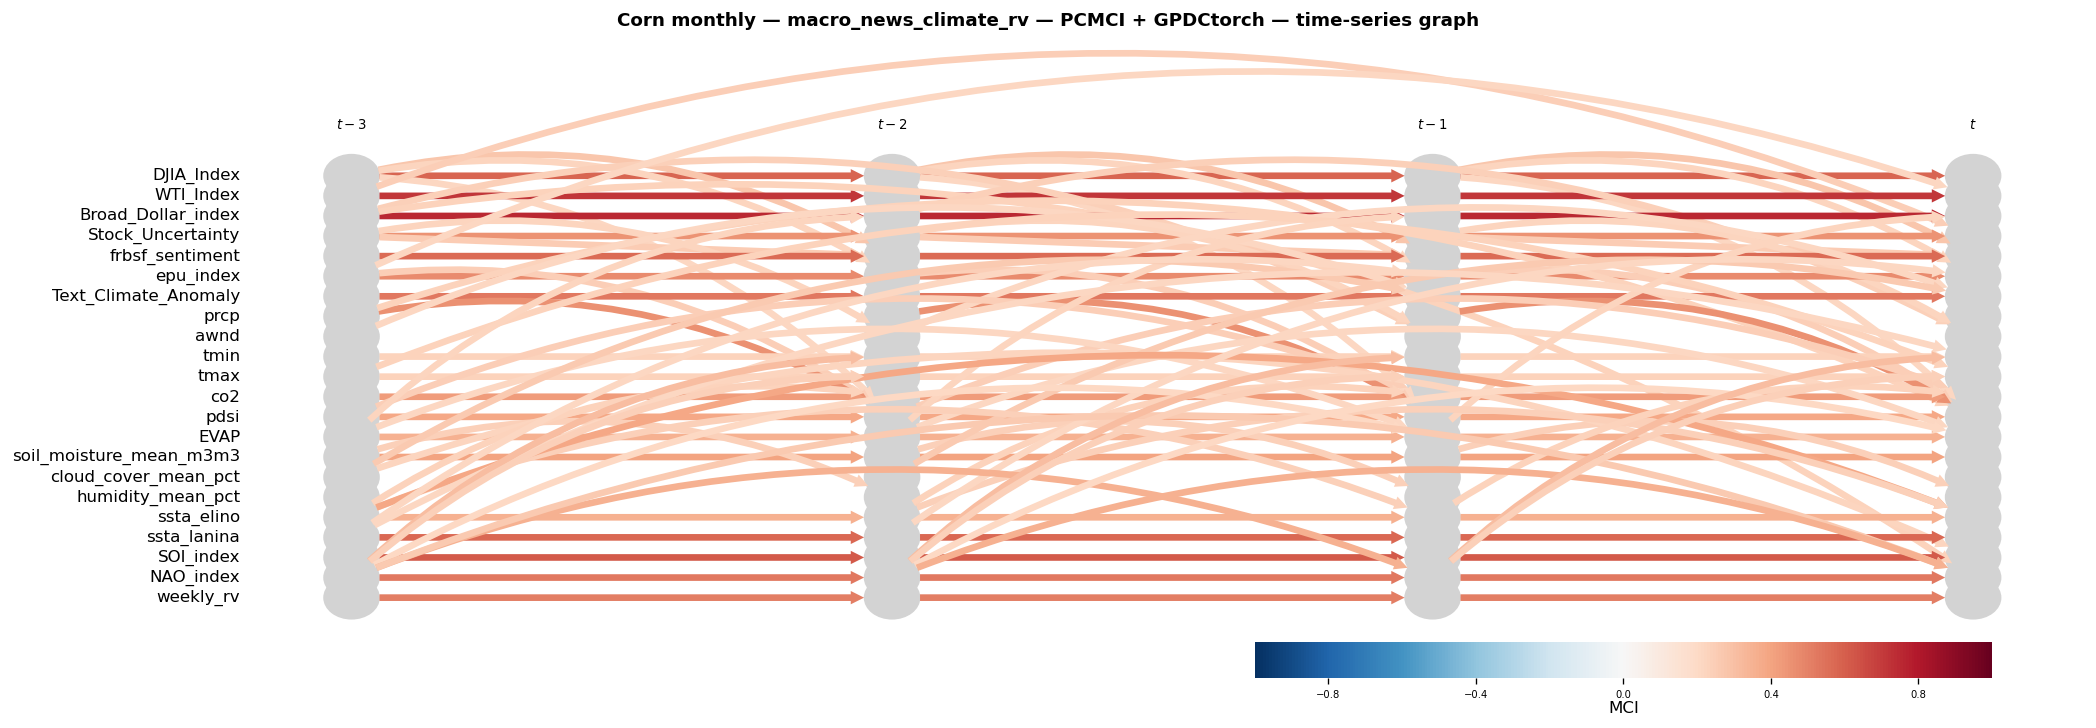


######################################################################
  Phase 2 | SOYBEAN  |  FREQUENCY: MONTHLY
######################################################################
  Preprocessed: (192, 22)  (2009-04-01 → 2025-03-01)

  ── climete (14 vars, tau_max=3) ──
  Elapsed: 141.6 s

## Significant links at alpha = 0.05:

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 3 link(s):
        (NAO_index -1): pval = 0.00000 | val =  0.240
        (tmin -1): pval = 0.00000 | val =  0.233
        (ssta_lanina -3): pval = 0.00000 | val =  0.208

    Variable tmax has 2 link(s):
        (tmax -1): pval = 0.00000 | val =  0.240
        (tmax -3): pval = 0.00000 | val =  0.237

    Variable co2 has 4 link(s):
        (co2 -1): pval = 0.00000 | val =  0.461
        (pdsi -2): pval = 0.00000 | val =  0.260
        (ssta_elino -1): pval = 0.00000 | val =  0.217
        (ssta_elino -3): pval = 0.00000 | val =  0.212

    Variable pdsi has 2 link(s)

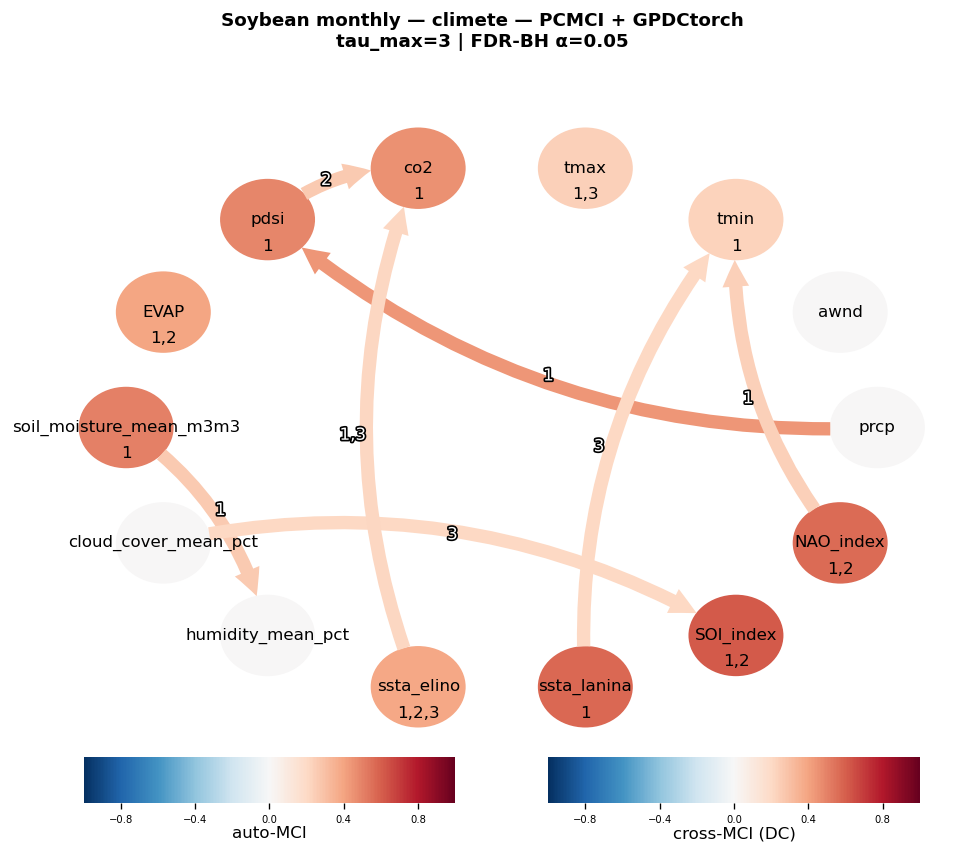

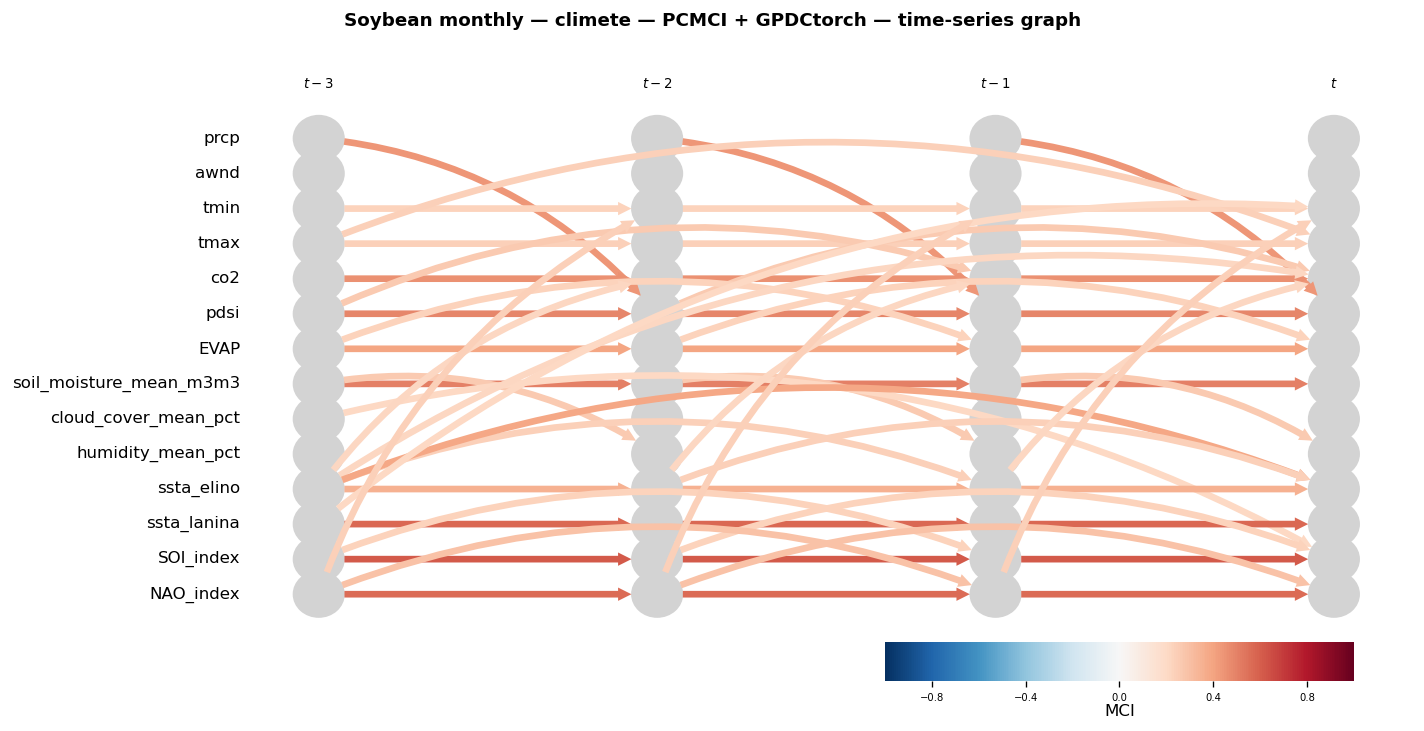


  ── climate_rv (15 vars, tau_max=3) ──
  Elapsed: 166.1 s

## Significant links at alpha = 0.05:

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 3 link(s):
        (NAO_index -1): pval = 0.00000 | val =  0.233
        (tmin -1): pval = 0.00000 | val =  0.224
        (ssta_lanina -3): pval = 0.00000 | val =  0.212

    Variable tmax has 2 link(s):
        (tmax -1): pval = 0.00000 | val =  0.240
        (tmax -3): pval = 0.00000 | val =  0.237

    Variable co2 has 5 link(s):
        (co2 -1): pval = 0.00000 | val =  0.461
        (pdsi -2): pval = 0.00000 | val =  0.260
        (ssta_elino -1): pval = 0.00000 | val =  0.217
        (ssta_elino -3): pval = 0.00000 | val =  0.212
        (weekly_rv -1): pval = 0.00000 | val =  0.210

    Variable pdsi has 2 link(s):
        (pdsi -1): pval = 0.00000 | val =  0.489
        (prcp -1): pval = 0.00000 | val =  0.438

    Variable EVAP has 2 link(s):
        (EVAP -1): pval = 0.00000 | val =  0.393

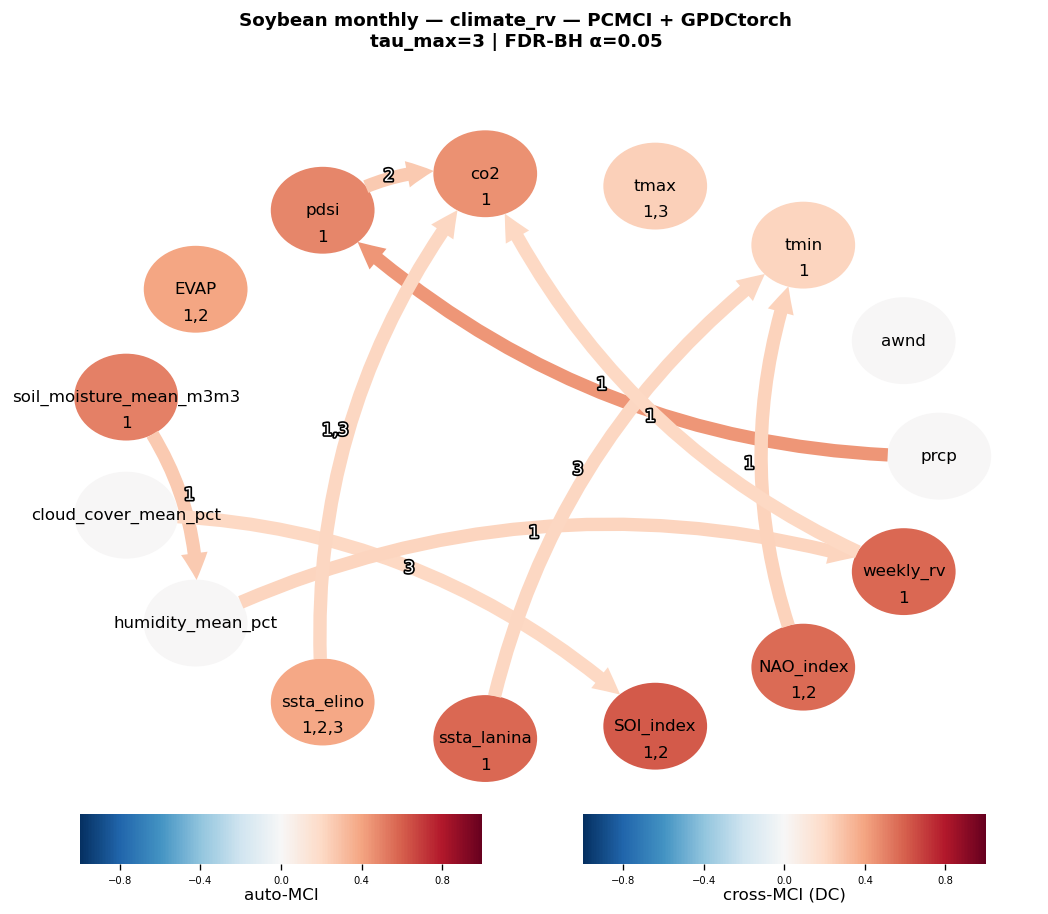

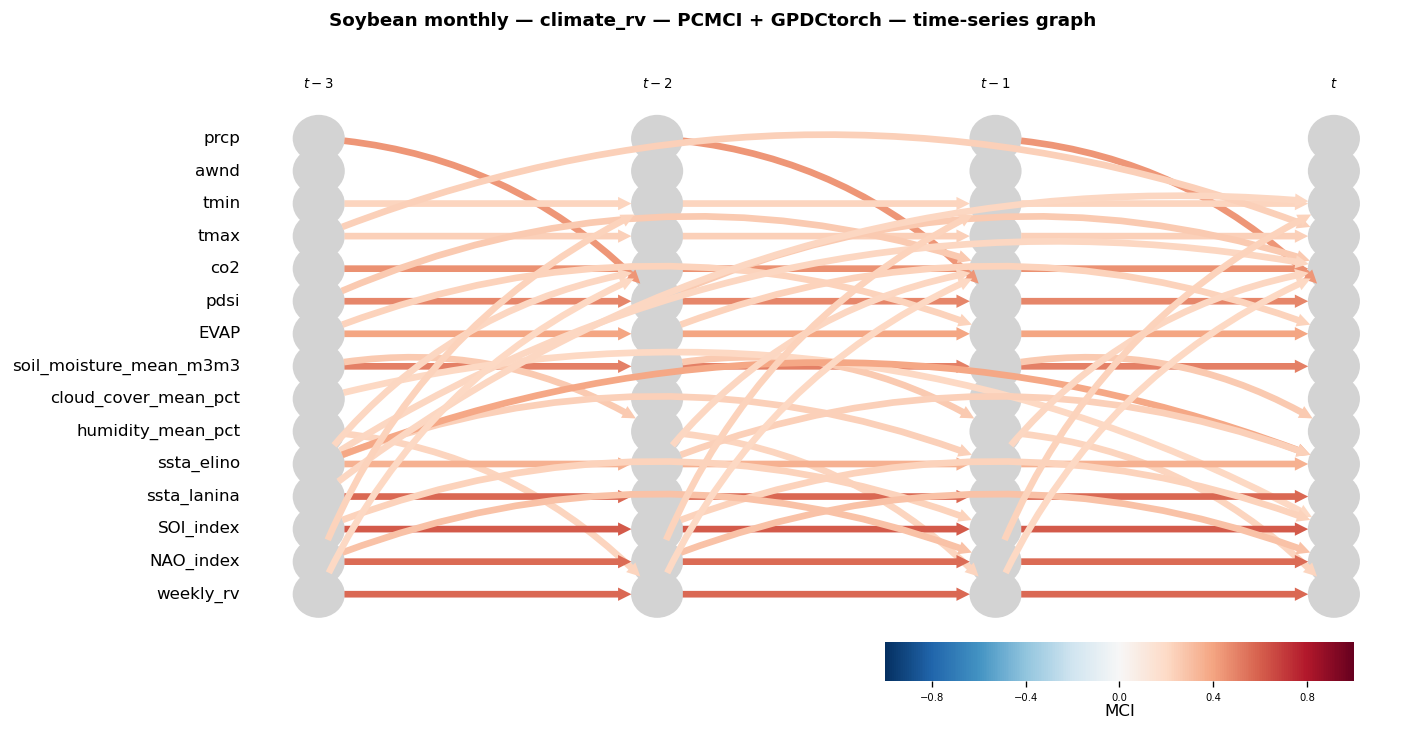


  ── macro_news_climate_rv (22 vars, tau_max=3) ──
  Elapsed: 388.0 s

## Significant links at alpha = 0.05:

    Variable DJIA_Index has 1 link(s):
        (DJIA_Index -1): pval = 0.00000 | val =  0.581

    Variable WTI_Index has 1 link(s):
        (WTI_Index -1): pval = 0.00000 | val =  0.724

    Variable Broad_Dollar_index has 2 link(s):
        (Broad_Dollar_index -1): pval = 0.00000 | val =  0.752
        (EVAP -1): pval = 0.00000 | val =  0.224

    Variable Stock_Uncertainty has 1 link(s):
        (Stock_Uncertainty -1): pval = 0.00000 | val =  0.446

    Variable frbsf_sentiment has 3 link(s):
        (frbsf_sentiment -1): pval = 0.00000 | val =  0.566
        (DJIA_Index -1): pval = 0.00000 | val =  0.278
        (Stock_Uncertainty -1): pval = 0.00000 | val =  0.253

    Variable epu_index has 3 link(s):
        (epu_index -1): pval = 0.00000 | val =  0.469
        (DJIA_Index -1): pval = 0.00000 | val =  0.224
        (ssta_lanina -2): pval = 0.00000 | val =  0.211

    Va

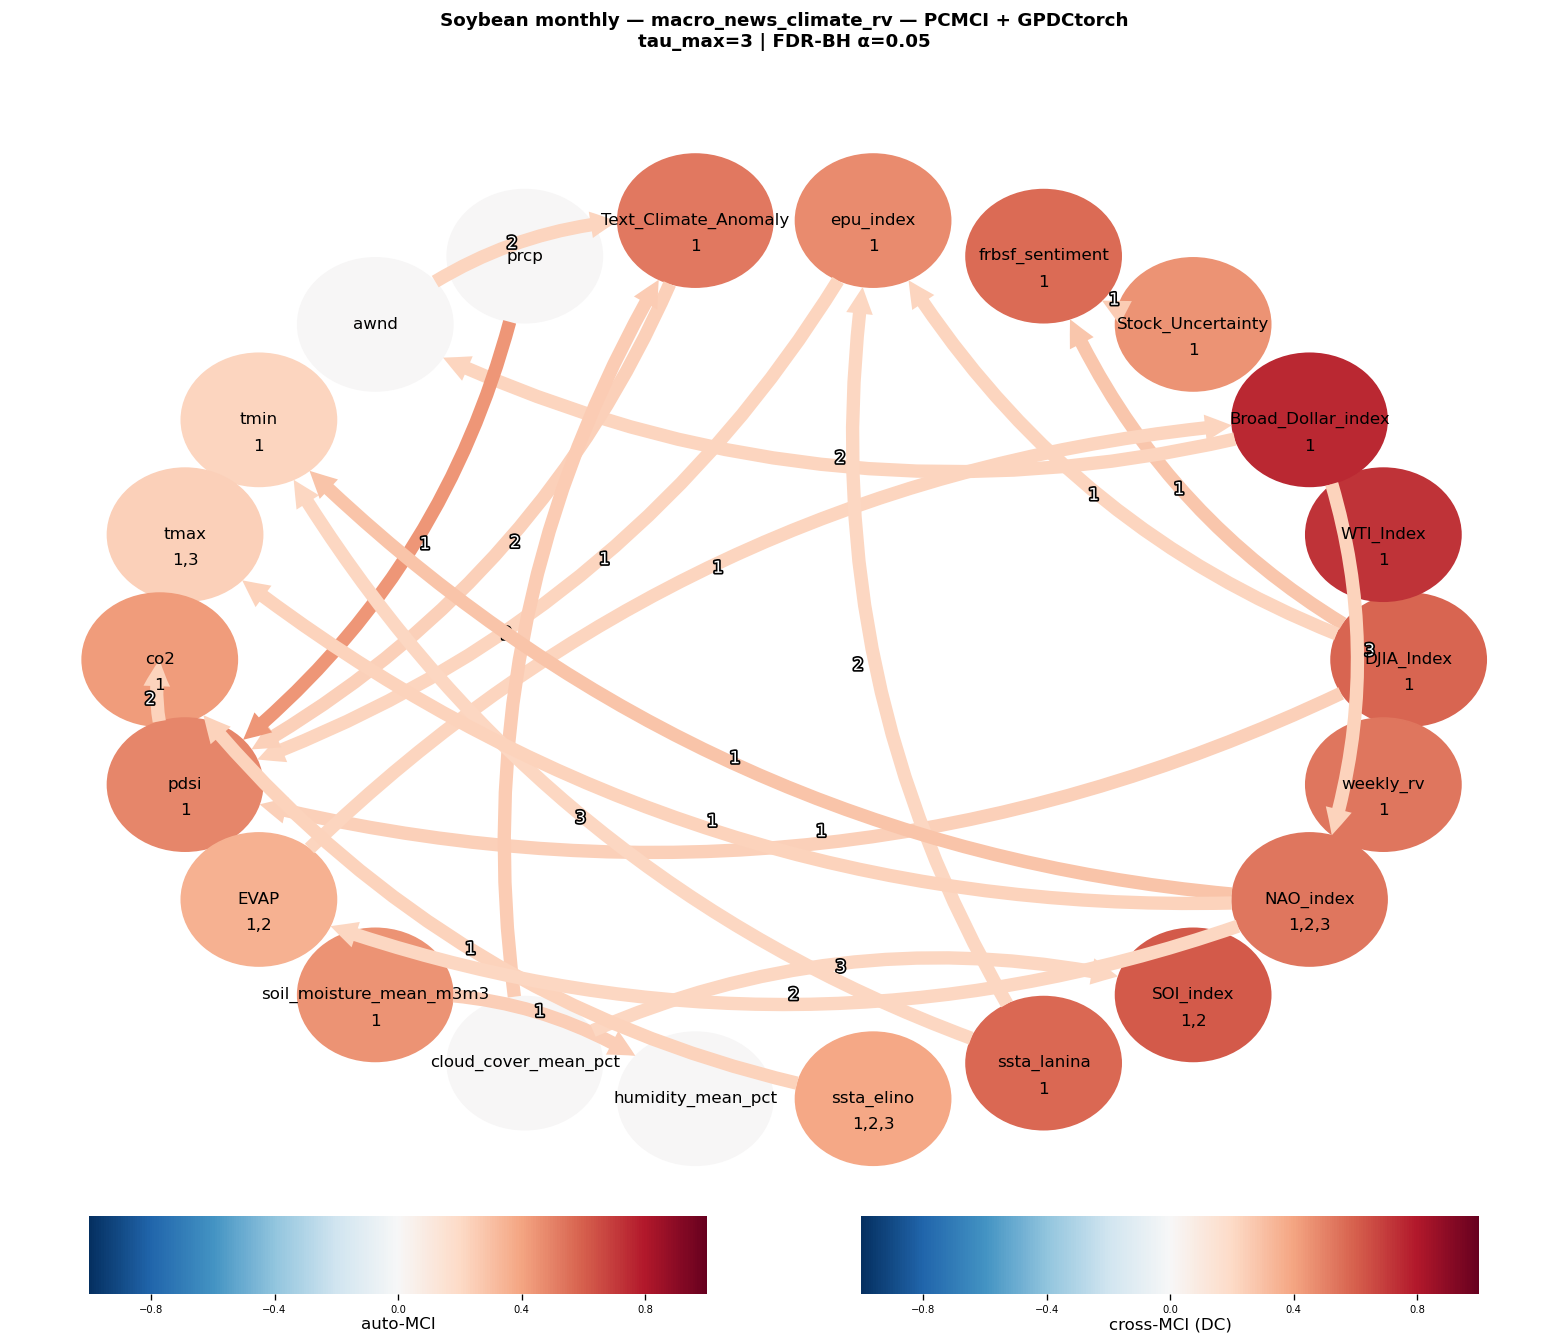

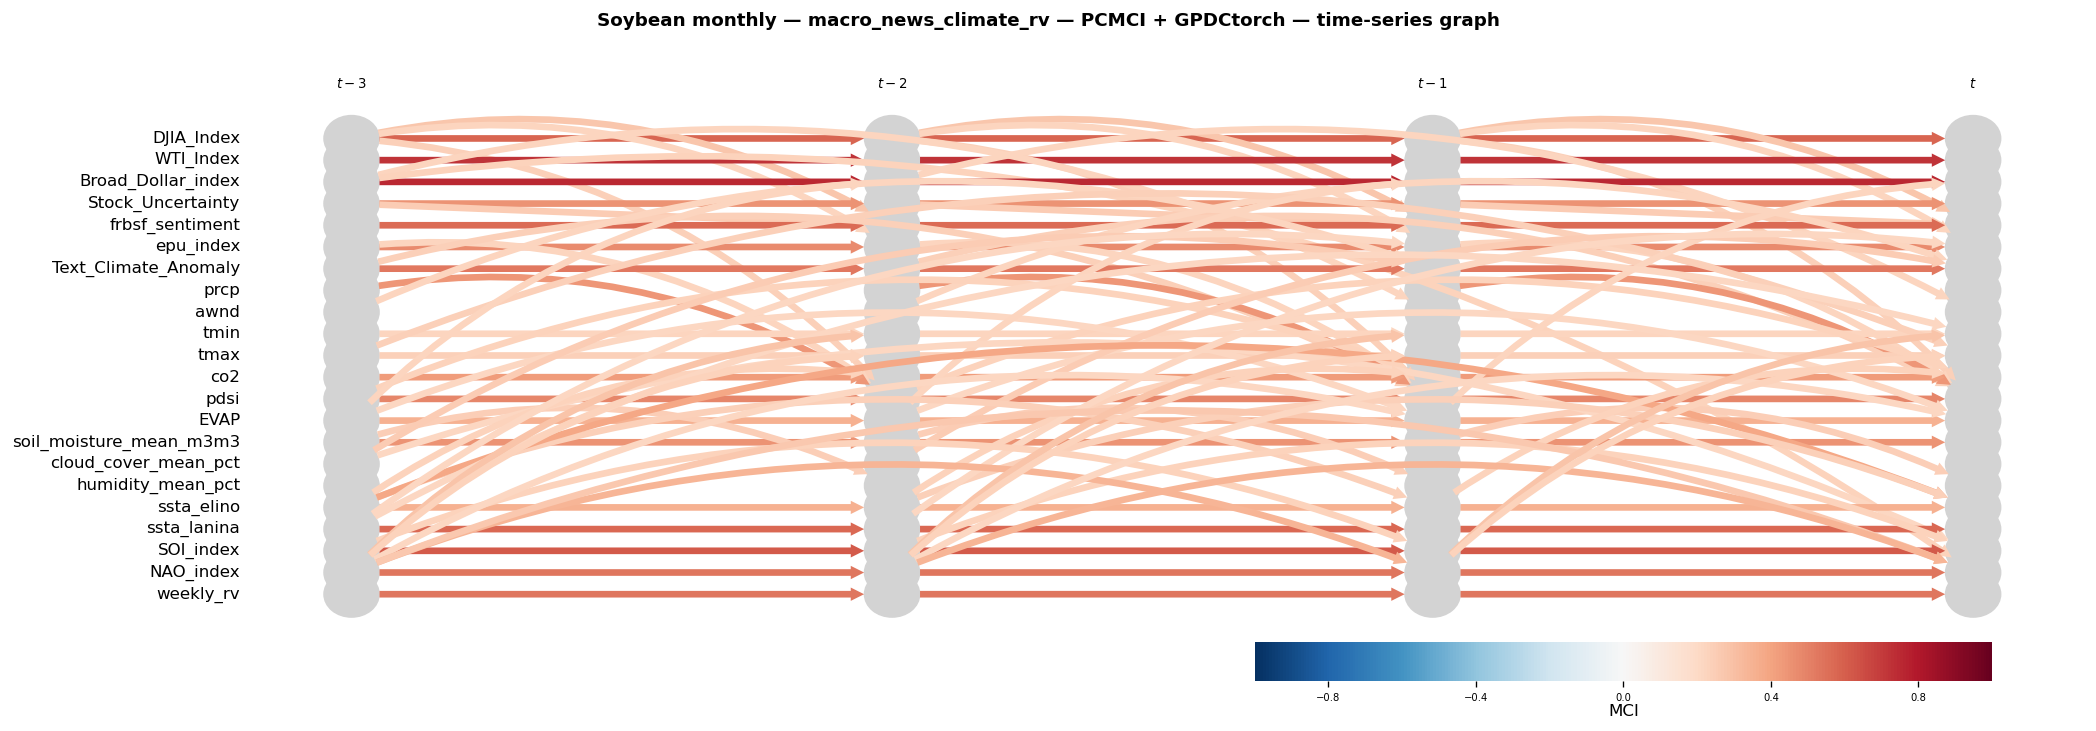


######################################################################
  Phase 2 | WHEAT  |  FREQUENCY: MONTHLY
######################################################################
  Preprocessed: (192, 22)  (2009-04-01 → 2025-03-01)

  ── climete (14 vars, tau_max=3) ──
  Elapsed: 151.3 s

## Significant links at alpha = 0.05:

    Variable prcp has 2 link(s):
        (NAO_index -2): pval = 0.00000 | val =  0.213
        (soil_moisture_mean_m3m3 -3): pval = 0.00000 | val =  0.208

    Variable awnd has 0 link(s):

    Variable tmin has 3 link(s):
        (NAO_index -1): pval = 0.00000 | val =  0.251
        (ssta_lanina -3): pval = 0.00000 | val =  0.249
        (tmin -1): pval = 0.00000 | val =  0.231

    Variable tmax has 1 link(s):
        (NAO_index -1): pval = 0.00000 | val =  0.250

    Variable co2 has 3 link(s):
        (co2 -1): pval = 0.00000 | val =  0.461
        (ssta_elino -1): pval = 0.00000 | val =  0.217
        (ssta_elino -3): pval = 0.00000 | val =  0.212

    

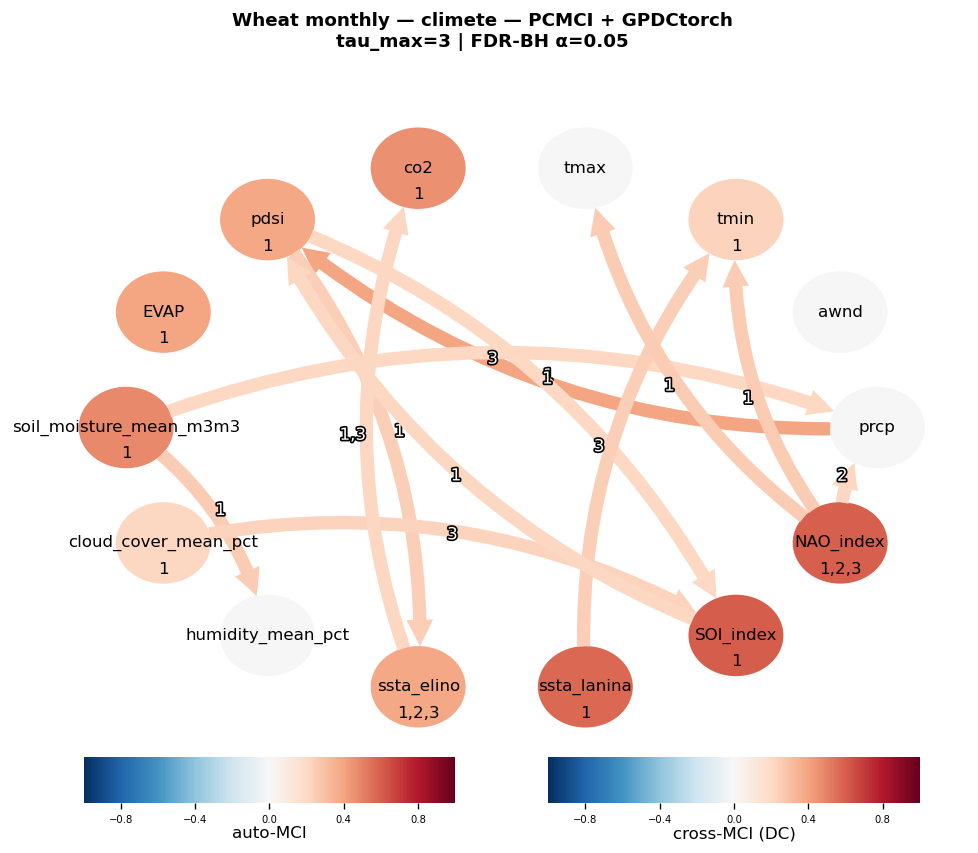

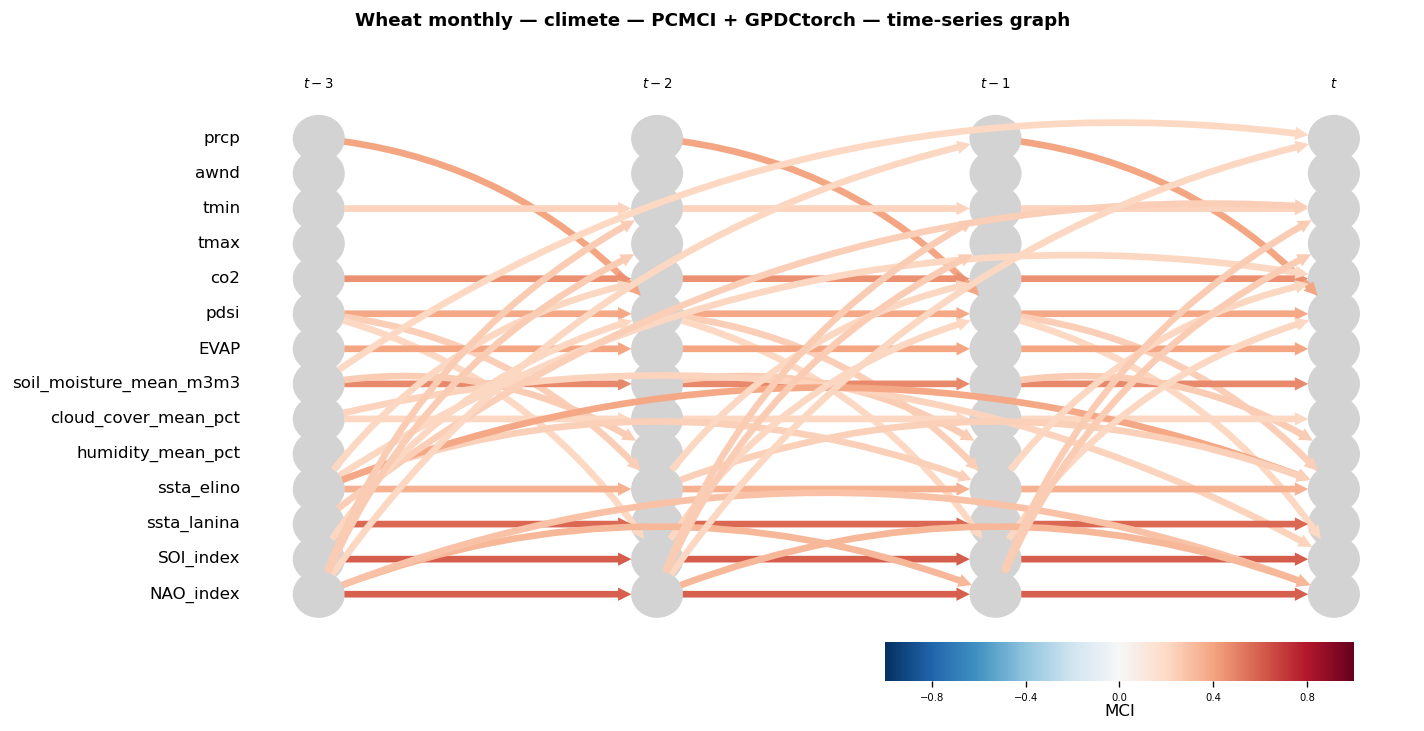


  ── climate_rv (15 vars, tau_max=3) ──
  Elapsed: 179.1 s

## Significant links at alpha = 0.05:

    Variable prcp has 2 link(s):
        (NAO_index -2): pval = 0.00000 | val =  0.213
        (soil_moisture_mean_m3m3 -3): pval = 0.00000 | val =  0.208

    Variable awnd has 0 link(s):

    Variable tmin has 3 link(s):
        (NAO_index -1): pval = 0.00000 | val =  0.251
        (ssta_lanina -3): pval = 0.00000 | val =  0.249
        (tmin -1): pval = 0.00000 | val =  0.231

    Variable tmax has 1 link(s):
        (NAO_index -1): pval = 0.00000 | val =  0.273

    Variable co2 has 3 link(s):
        (co2 -1): pval = 0.00000 | val =  0.461
        (ssta_elino -1): pval = 0.00000 | val =  0.217
        (ssta_elino -3): pval = 0.00000 | val =  0.212

    Variable pdsi has 4 link(s):
        (prcp -1): pval = 0.00000 | val =  0.392
        (pdsi -1): pval = 0.00000 | val =  0.388
        (SOI_index -1): pval = 0.00000 | val =  0.218
        (tmax -3): pval = 0.00000 | val =  0.207

   

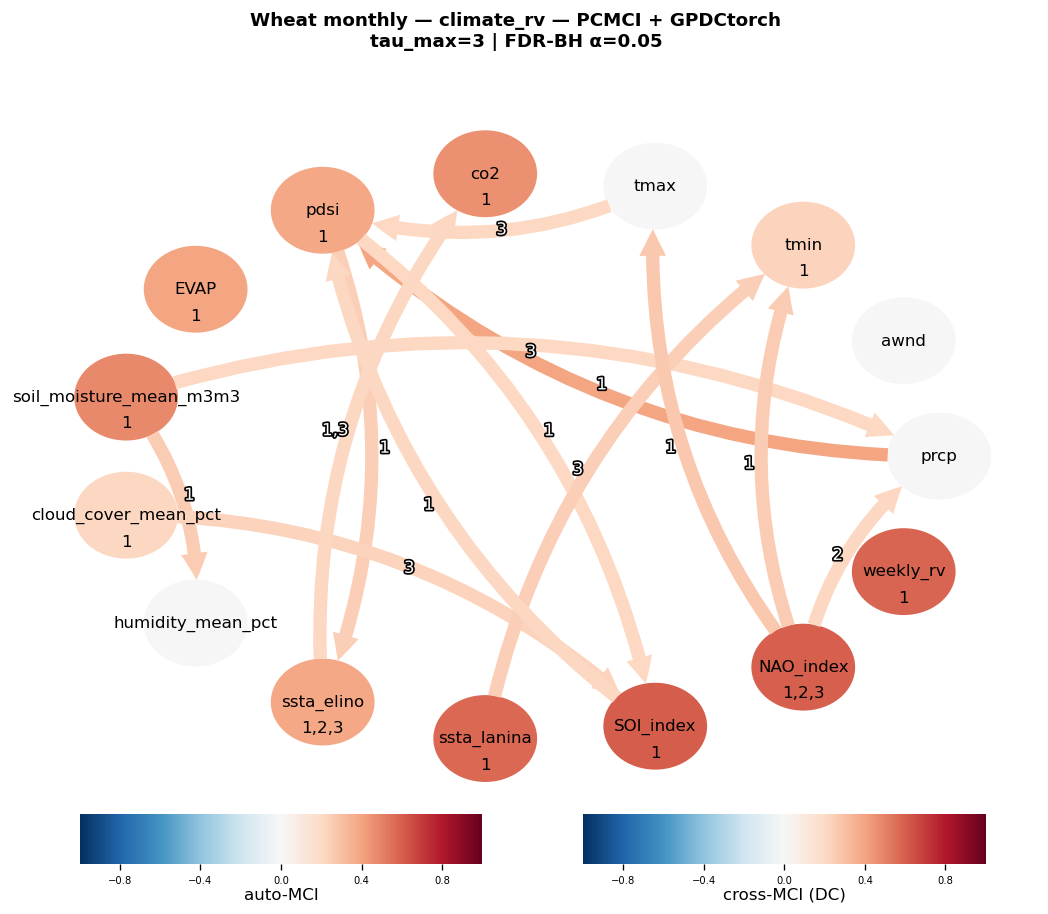

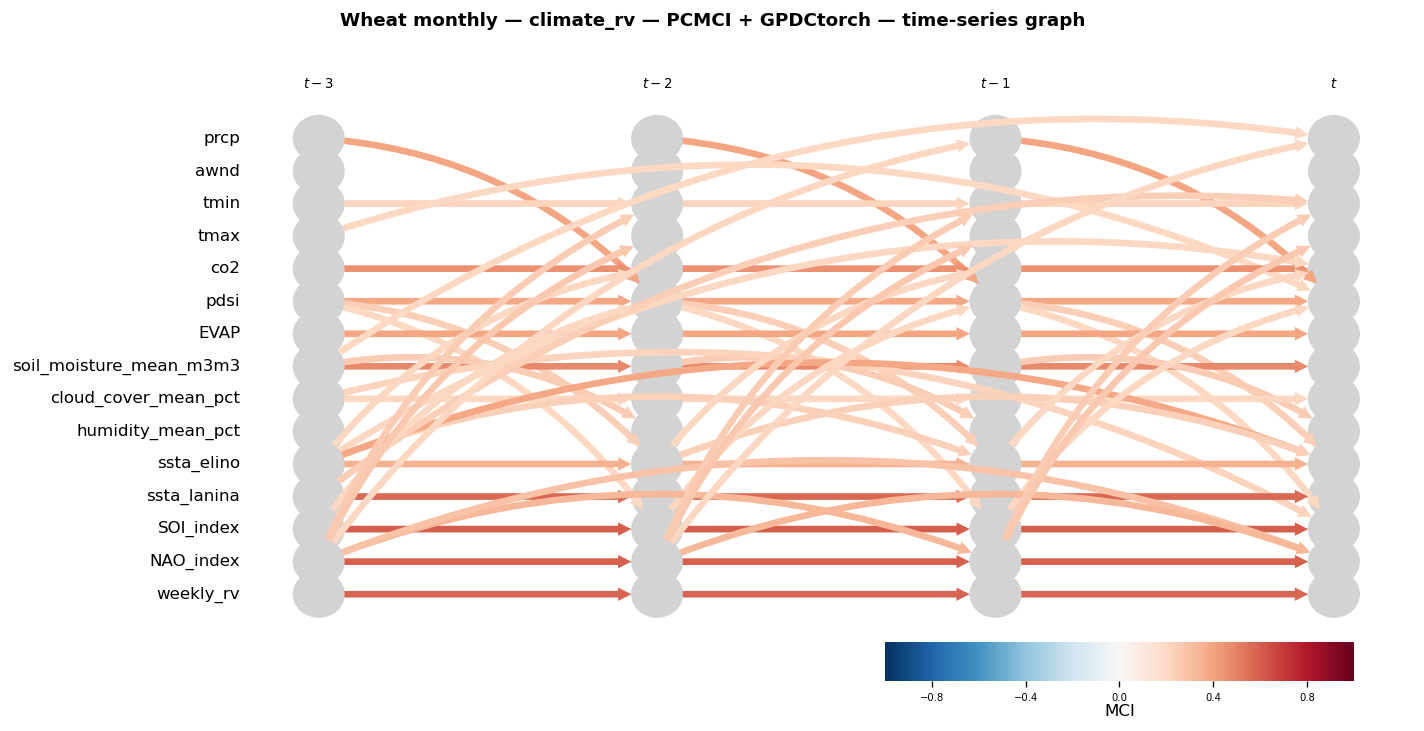


  ── macro_news_climate_rv (22 vars, tau_max=3) ──


In [ ]:
# Phase 2: per-crop RV analysis — climate_rv and macro_news_climate_rv only
RV_FEATURE_SETS = {
    'climete'              : ['climate'],
    'climate_rv'           : ['climate', 'rv'],
    'macro_news_climate_rv': ['macro', 'news', 'climate', 'rv'],
}

all_results: dict[str, dict] = {}

for crop in CROPS:
    print(f'\n{"#"*70}')
    print(f'  Phase 2 | {crop.upper()}  |  FREQUENCY: {FREQUENCY.upper()}')
    print(f'{"#"*70}')

    arr_normal, all_cols, dates = load_and_preprocess(crop, FREQUENCY)
    print(f'  Preprocessed: {arr_normal.shape}  '
          f'({dates.min().date()} → {dates.max().date()})')

    all_results[crop] = {}

    for fs_name, groups in RV_FEATURE_SETS.items():
        col_names = [c for c in build_cols(groups) if c in all_cols]

        t0  = time.time()
        res = run_gpdc(
            feature_set_name=fs_name,
            col_names=col_names,
            arr_preprocessed=arr_normal,
            all_cols=all_cols,
            tau_max=TAU_MAX,
            pc_alpha=PC_ALPHA,
            alpha_level=ALPHA_LEVEL,
            fdr_method=FDR_METHOD,
            max_combinations=MAX_COMBINATIONS,
            max_conds_dim=None,
            verbosity=0,
        )
        elapsed = time.time() - t0
        all_results[crop][fs_name] = res

        print(f'  Elapsed: {elapsed:.1f} s')
        res['pcmci'].print_significant_links(
            p_matrix=res['q_matrix'],
            val_matrix=res['val_matrix'],
            alpha_level=ALPHA_LEVEL,
        )
        plot_results(
            res,
            title=f'{crop.capitalize()} {FREQUENCY} — {fs_name} — PCMCI + GPDCtorch',
            tau_max=TAU_MAX,
        )

print('\nPhase 2 done.')

## 7. Cross-Crop Comparison: Significant Links into `weekly_rv`

In [ ]:
for fs_name in ['climate_rv', 'macro_news_climate_rv']:
    print(f'\n{"="*65}')
    print(f'  Feature set: {fs_name}')
    print(f'{"="*65}')
    for crop in CROPS:
        links = extract_rv_links(all_results[crop][fs_name])
        print(f'\n  {crop.upper()}:')
        if links.empty:
            print('    No significant links into weekly_rv.')
        else:
            print(links.sort_values('q_val').to_string(
                index=False, float_format='{:.3f}'.format, col_space=18))

In [ ]:
# ── Bar charts: MCI into weekly_rv, one panel per crop ───────────────────────
for fs_name in ['climate_rv', 'macro_news_climate_rv']:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

    for ax, crop in zip(axes, CROPS):
        links = extract_rv_links(all_results[crop][fs_name])
        if links.empty:
            ax.set_title(f'{crop.capitalize()}\n(no significant links)', fontsize=10)
            continue
        labels = [f"{r['cause']} (τ={r['lag']})" for _, r in links.iterrows()]
        vals   = links['val'].values
        colors = [GROUP_COLORS.get(group_of(r['cause']), '#888') for _, r in links.iterrows()]
        ax.barh(labels, vals, color=colors, alpha=0.85)
        ax.axvline(0, color='k', lw=0.8)
        ax.set_xlabel('MCI (Distance Corr.)')
        ax.set_title(f'{crop.capitalize()}', fontsize=11, fontweight='bold')
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)

    handles = [Patch(facecolor=c, label=g) for g, c in GROUP_COLORS.items()]
    fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=9)
    fig.suptitle(
        f'Significant causal links into weekly_rv — {fs_name}\n'
        f'{FREQUENCY.capitalize()} | PCMCI + GPDCtorch | tau_max={TAU_MAX} | FDR-BH α=0.05',
        fontsize=11, fontweight='bold',
    )
    plt.tight_layout()
    plt.show()

## 8. GPDCtorch vs ParCorr: Unique Links into `weekly_rv`

Links that GPDCtorch finds but ParCorr misses are evidence of **nonlinear additive** causation.

In [ ]:
# ── Summarise: which variables Granger-cause RV per crop (climate_rv set) ─────
print('Granger-causes of weekly_rv found by GPDCtorch (climate_rv, τ≤3):')
print(f'{"Crop":12s}  {"Cause":35s}  {"Lag":5s}  {"MCI val":10s}  {"q-val":8s}')
print('-' * 75)

for crop in CROPS:
    links = extract_rv_links(all_results[crop]['climate_rv'])
    if links.empty:
        print(f'{crop:12s}  (none)')
    else:
        for _, row in links.sort_values('q_val').iterrows():
            print(f"{crop:12s}  {row['cause']:35s}  τ={row['lag']:1d}  "
                  f"{row['val']:+.4f}      {row['q_val']:.4f}")

## 9. Summary

**Preprocessing (identical to `eda_preprocessing.ipynb`):**
- Interpolate `pdsi`, `Broad_Dollar_index` | ffill `DJIA_Index`
- `pp.smooth(smooth_width=180, kernel='gaussian', residuals=True)` — 15-yr Gaussian detrend
- Phase-wise anomalization (`cycle_length=12`)
- `pp.trafo2normal` — rank-based Gaussianisation

**PCMCI + GPDCtorch config:**

| Parameter | Value | Reason |
|-----------|-------|--------|
| `tau_max` | 3 | GP conditioning sets grow with tau; tau=3 balances detection and runtime |
| `pc_alpha` | 0.1 | Tighter than ParCorr; GPDC has lower power for linear links |
| `max_combinations` | 1 | Limits GP fits per link; primary runtime control |
| `significance` | `analytic` | Pre-computes null once; avoids per-test shuffle |
| `alpha_level` | 0.05 | Final FDR-BH significance threshold |

**Interpreting results:**
- MCI value = Distance Correlation on GP residuals; links GPDCtorch finds that ParCorr misses = nonlinear additive dependencies
- Links ParCorr finds that GPDCtorch misses = linear links below GPDC's power at tau_max=3